In [ ]:
import re
import math
import random
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [ ]:
data = [
    ("i loved this movie it was funny warm and charming", 1),
    ("this film was wonderful and beautifully acted", 1),
    ("i really liked the story and the characters", 1),
    ("an excellent movie with a great ending", 1),
    ("boring slow and predictable i hated it", 0),
    ("this movie was terrible and badly written", 0),
    ("awful acting and a very weak plot", 0),
    ("i did not enjoy this film at all", 0),
    ("the movie was good and surprisingly touching", 1),
    ("what a fantastic and enjoyable film", 1),
    ("this was dull messy and disappointing", 0),
    ("one of the worst movies i have seen", 0),
]

random.seed(0)
random.shuffle(data)

train_data = data[:10]
val_data = data[10:]

In [ ]:
def tokenize(text):
    return re.findall(r"[a-z']+", text.lower())

counter = Counter()
for text, _ in train_data:
    counter.update(tokenize(text))

specials = ["<pad>", "<unk>"]
itos = specials + [w for w, c in counter.items() if c >= 1]
stoi = {w: i for i, w in enumerate(itos)}

PAD_ID = stoi["<pad>"]
UNK_ID = stoi["<unk>"]

def encode(text):
    return [stoi.get(tok, UNK_ID) for tok in tokenize(text)]

max_len = max(len(tokenize(text)) for text, _ in data)


In [ ]:
class TextDataset(Dataset):
    def __init__(self, items):
        self.items = items

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        text, label = self.items[idx]
        ids = encode(text)[:max_len]
        attn = [1] * len(ids)

        while len(ids) < max_len:
            ids.append(PAD_ID)
            attn.append(0)

        return (
            torch.tensor(ids, dtype=torch.long),
            torch.tensor(attn, dtype=torch.float32),
            torch.tensor(label, dtype=torch.long),
        )

train_ds = TextDataset(train_data)
val_ds = TextDataset(val_data)

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=4)

In [ ]:
class TinySelectiveSSM(nn.Module):
    def __init__(self, d_model=32, d_state=32):
        super().__init__()
        self.d_model = d_model
        self.d_state = d_state

        self.A_log = nn.Parameter(torch.zeros(d_state))
        self.to_B = nn.Linear(d_model, d_state)
        self.to_C = nn.Linear(d_model, d_state)
        self.to_delta = nn.Linear(d_model, d_state)
        self.in_proj = nn.Linear(d_model, d_state)

    def forward(self, x, mask=None, return_trace=False):
        """
        x: [B, L, d_model]
        mask: [B, L]
        """
        B, L, _ = x.shape
        h = torch.zeros(B, self.d_state, device=x.device)
        ys = []

        trace = None
        if return_trace:
            trace = {
                "delta": [],
                "A_t": [],
                "B_t": [],
                "C_t": [],
                "update_norm": [],
                "state_norm": [],
            }

        A_cont = -torch.exp(self.A_log)  # [d_state]

        for t in range(L):
            x_t = x[:, t, :]              # [B, d_model]
            h_prev = h.clone()

            delta_t = torch.nn.functional.softplus(self.to_delta(x_t))   # [B, d_state]
            A_t = torch.exp(delta_t * A_cont.unsqueeze(0))               # [B, d_state]
            B_t = torch.sigmoid(self.to_B(x_t))                          # [B, d_state]
            C_t = torch.sigmoid(self.to_C(x_t))                          # [B, d_state]
            u_t = self.in_proj(x_t)                                      # [B, d_state]

            h = A_t * h + B_t * u_t
            y_t = C_t * h

            if mask is not None:
                m_t = mask[:, t].unsqueeze(-1)   # [B, 1]
                h = m_t * h + (1 - m_t) * h_prev
                y_t = m_t * y_t

            ys.append(y_t.unsqueeze(1))

            if return_trace:
                trace["delta"].append(delta_t.detach().cpu())
                trace["A_t"].append(A_t.detach().cpu())
                trace["B_t"].append(B_t.detach().cpu())
                trace["C_t"].append(C_t.detach().cpu())
                trace["update_norm"].append((h - h_prev).norm(dim=-1).detach().cpu())
                trace["state_norm"].append(h.norm(dim=-1).detach().cpu())

        y_seq = torch.cat(ys, dim=1)  # [B, L, d_state]

        if return_trace:
            for k in trace:
                trace[k] = torch.stack(trace[k], dim=1)
            return y_seq, h, trace

        return y_seq, h


In [ ]:
class TinySSMClassifier(nn.Module):
    def __init__(self, vocab_size, d_model=32, d_state=32, num_classes=2):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        self.ssm = TinySelectiveSSM(d_model=d_model, d_state=d_state)
        self.norm = nn.LayerNorm(d_state)
        self.head = nn.Linear(d_state, num_classes)

    def forward(self, ids, mask, return_trace=False):
        x = self.embed(ids)

        if return_trace:
            y_seq, h_last, trace = self.ssm(x, mask, return_trace=True)
        else:
            y_seq, h_last = self.ssm(x, mask, return_trace=False)
            trace = None

        lengths = mask.sum(dim=1).long() - 1
        pooled = y_seq[torch.arange(ids.size(0), device=ids.device), lengths]

        logits = self.head(self.norm(pooled))

        if return_trace:
            return logits, trace
        return logits

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TinySSMClassifier(vocab_size=len(itos), d_model=32, d_state=32).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

def evaluate(loader):
    model.eval()
    total = 0
    correct = 0
    loss_sum = 0.0
    with torch.no_grad():
        for ids, mask, labels in loader:
            ids, mask, labels = ids.to(device), mask.to(device), labels.to(device)
            logits = model(ids, mask)
            loss = criterion(logits, labels)
            loss_sum += loss.item() * ids.size(0)
            preds = logits.argmax(dim=-1)
            correct += (preds == labels).sum().item()
            total += ids.size(0)
    return loss_sum / total, correct / total

for epoch in range(20):
    model.train()
    for ids, mask, labels in train_loader:
        ids, mask, labels = ids.to(device), mask.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(ids, mask)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

    train_loss, train_acc = evaluate(train_loader)
    val_loss, val_acc = evaluate(val_loader)
    print(f"epoch {epoch+1:02d} | train loss {train_loss:.3f} acc {train_acc:.2f} | val loss {val_loss:.3f} acc {val_acc:.2f}")

epoch 01 | train loss 0.714 acc 0.60 | val loss 0.701 acc 0.50
epoch 02 | train loss 0.636 acc 0.60 | val loss 0.687 acc 0.50
epoch 03 | train loss 0.567 acc 0.60 | val loss 0.673 acc 0.50
epoch 04 | train loss 0.505 acc 0.70 | val loss 0.662 acc 0.50
epoch 05 | train loss 0.449 acc 1.00 | val loss 0.650 acc 0.50
epoch 06 | train loss 0.400 acc 1.00 | val loss 0.643 acc 0.50
epoch 07 | train loss 0.356 acc 1.00 | val loss 0.635 acc 0.50
epoch 08 | train loss 0.318 acc 1.00 | val loss 0.628 acc 1.00
epoch 09 | train loss 0.283 acc 1.00 | val loss 0.616 acc 1.00
epoch 10 | train loss 0.252 acc 1.00 | val loss 0.600 acc 1.00
epoch 11 | train loss 0.224 acc 1.00 | val loss 0.586 acc 1.00
epoch 12 | train loss 0.200 acc 1.00 | val loss 0.576 acc 1.00
epoch 13 | train loss 0.178 acc 1.00 | val loss 0.563 acc 1.00
epoch 14 | train loss 0.159 acc 1.00 | val loss 0.551 acc 1.00
epoch 15 | train loss 0.142 acc 1.00 | val loss 0.536 acc 1.00
epoch 16 | train loss 0.127 acc 1.00 | val loss 0.524 a

In [ ]:
def predict_text(model, text, stoi, max_len, device):
    model.eval()

    def tokenize(text):
        import re
        return re.findall(r"[a-z']+", text.lower())

    PAD_ID = stoi["<pad>"]
    UNK_ID = stoi["<unk>"]

    ids = [stoi.get(tok, UNK_ID) for tok in tokenize(text)][:max_len]
    mask = [1] * len(ids)

    while len(ids) < max_len:
        ids.append(PAD_ID)
        mask.append(0)

    ids = torch.tensor([ids], dtype=torch.long).to(device)
    mask = torch.tensor([mask], dtype=torch.float32).to(device)

    with torch.no_grad():
        logits = model(ids, mask)
        probs = torch.softmax(logits, dim=-1)
        pred = probs.argmax(dim=-1).item()

    return {
        "text": text,
        "pred_label": pred,
        "probs": probs[0].cpu().numpy(),
        "tokens": tokenize(text),
    }

examples = [
    "this movie was wonderful and touching",
    "boring slow and badly written film",
    "great acting but the plot was dull",
]

for ex in examples:
    out = predict_text(model, ex, stoi, max_len, device)
    print("TEXT:", out["text"])
    print("TOKENS:", out["tokens"])
    print("PRED:", out["pred_label"], "PROBS:", out["probs"])
    print("-" * 60)

TEXT: this movie was wonderful and touching
TOKENS: ['this', 'movie', 'was', 'wonderful', 'and', 'touching']
PRED: 1 PROBS: [0.20319358 0.79680645]
------------------------------------------------------------
TEXT: boring slow and badly written film
TOKENS: ['boring', 'slow', 'and', 'badly', 'written', 'film']
PRED: 1 PROBS: [0.33136213 0.6686379 ]
------------------------------------------------------------
TEXT: great acting but the plot was dull
TOKENS: ['great', 'acting', 'but', 'the', 'plot', 'was', 'dull']
PRED: 1 PROBS: [0.17775147 0.8222485 ]
------------------------------------------------------------


In [ ]:
def inspect_example(model, text, stoi, max_len, device):
    import re

    def tokenize(text):
        return re.findall(r"[a-z']+", text.lower())

    PAD_ID = stoi["<pad>"]
    UNK_ID = stoi["<unk>"]

    tokens = tokenize(text)
    ids = [stoi.get(tok, UNK_ID) for tok in tokens][:max_len]
    mask = [1] * len(ids)

    while len(ids) < max_len:
        ids.append(PAD_ID)
        mask.append(0)

    ids_t = torch.tensor([ids], dtype=torch.long).to(device)
    mask_t = torch.tensor([mask], dtype=torch.float32).to(device)

    model.eval()
    with torch.no_grad():
        logits, trace = model(ids_t, mask_t, return_trace=True)
        probs = torch.softmax(logits, dim=-1)[0].cpu().numpy()

    valid_len = len(tokens)

    update_norm = trace["update_norm"][0, :valid_len].numpy()
    state_norm = trace["state_norm"][0, :valid_len].numpy()
    delta_mean = trace["delta"][0, :valid_len].mean(dim=-1).numpy()
    B_mean = trace["B_t"][0, :valid_len].mean(dim=-1).numpy()
    C_mean = trace["C_t"][0, :valid_len].mean(dim=-1).numpy()

    print("TEXT:", text)
    print("PRED PROBS:", probs)
    print()
    print(f"{'token':<15} {'delta':>8} {'B_mean':>8} {'C_mean':>8} {'upd_norm':>10} {'state_norm':>11}")
    print("-" * 70)
    for tok, d, b, c, u, s in zip(tokens, delta_mean, B_mean, C_mean, update_norm, state_norm):
        print(f"{tok:<15} {d:>8.3f} {b:>8.3f} {c:>8.3f} {u:>10.3f} {s:>11.3f}")

In [ ]:
inspect_example(model, "this movie was wonderful and touching", stoi, max_len, device)
inspect_example(model, "boring slow and badly written film", stoi, max_len, device)

TEXT: this movie was wonderful and touching
PRED PROBS: [0.20319358 0.79680645]

token              delta   B_mean   C_mean   upd_norm  state_norm
----------------------------------------------------------------------
this               0.683    0.497    0.488      1.127       1.127
movie              0.690    0.509    0.467      1.806       1.656
was                0.762    0.487    0.497      1.946       1.680
wonderful          0.737    0.495    0.492      2.080       2.001
and                0.734    0.479    0.462      2.016       2.009
touching           0.758    0.480    0.472      1.401       1.536
TEXT: boring slow and badly written film
PRED PROBS: [0.33136213 0.6686379 ]

token              delta   B_mean   C_mean   upd_norm  state_norm
----------------------------------------------------------------------
boring             0.799    0.508    0.517      1.778       1.778
slow               0.832    0.488    0.492      1.697       2.016
and                0.734    0.479    0.

In [ ]:
import matplotlib.pyplot as plt

def plot_token_selection(model, text, stoi, max_len, device):
    import re

    def tokenize(text):
        return re.findall(r"[a-z']+", text.lower())

    PAD_ID = stoi["<pad>"]
    UNK_ID = stoi["<unk>"]

    tokens = tokenize(text)
    ids = [stoi.get(tok, UNK_ID) for tok in tokens][:max_len]
    mask = [1] * len(ids)

    while len(ids) < max_len:
        ids.append(PAD_ID)
        mask.append(0)

    ids_t = torch.tensor([ids], dtype=torch.long).to(device)
    mask_t = torch.tensor([mask], dtype=torch.float32).to(device)

    model.eval()
    with torch.no_grad():
        logits, trace = model(ids_t, mask_t, return_trace=True)

    valid_len = len(tokens)
    update_norm = trace["update_norm"][0, :valid_len].numpy()
    delta_mean = trace["delta"][0, :valid_len].mean(dim=-1).numpy()

    plt.figure(figsize=(10, 4))
    plt.plot(update_norm, marker="o", label="||h_t - h_{t-1}||")
    plt.plot(delta_mean, marker="s", label="mean(delta_t)")
    plt.xticks(range(valid_len), tokens, rotation=45, ha="right")
    plt.ylabel("value")
    plt.title("Selective SSM token-wise updates")
    plt.legend()
    plt.tight_layout()
    plt.show()

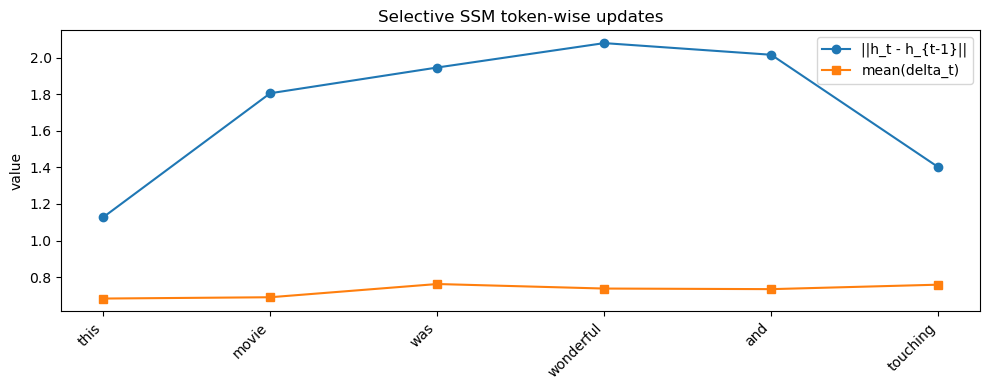

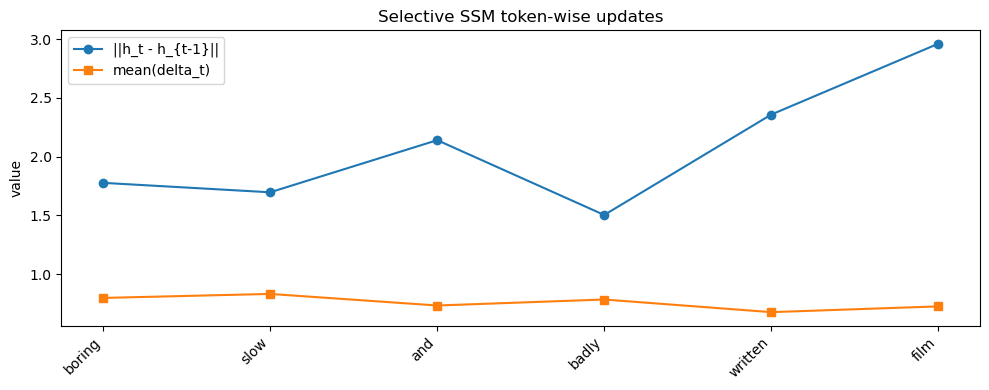

In [ ]:
plot_token_selection(model, "this movie was wonderful and touching", stoi, max_len, device)
plot_token_selection(model, "boring slow and badly written film", stoi, max_len, device)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_heatmap(model, text, stoi, max_len, device):
    import re

    def tokenize(text):
        return re.findall(r"[a-z']+", text.lower())

    PAD_ID = stoi["<pad>"]
    UNK_ID = stoi["<unk>"]

    tokens = tokenize(text)
    ids = [stoi.get(tok, UNK_ID) for tok in tokens][:max_len]
    mask = [1] * len(ids)

    while len(ids) < max_len:
        ids.append(PAD_ID)
        mask.append(0)

    ids_t = torch.tensor([ids], dtype=torch.long).to(device)
    mask_t = torch.tensor([mask], dtype=torch.float32).to(device)

    model.eval()
    with torch.no_grad():
        _, trace = model(ids_t, mask_t, return_trace=True)

    valid_len = len(tokens)
    B_t = trace["B_t"][0, :valid_len].numpy()  # [L, d_state]

    plt.figure(figsize=(10, 4))
    plt.imshow(B_t.T, aspect="auto")
    plt.xticks(range(valid_len), tokens, rotation=45, ha="right")
    plt.ylabel("state dim")
    plt.xlabel("token")
    plt.title("B_t heatmap across tokens")
    plt.colorbar()
    plt.tight_layout()
    plt.show()

In [ ]:
from collections import defaultdict
import numpy as np

def average_token_update_over_dataset(model, dataset_items, stoi, max_len, device):
    import re

    def tokenize(text):
        return re.findall(r"[a-z']+", text.lower())

    PAD_ID = stoi["<pad>"]
    UNK_ID = stoi["<unk>"]

    stats = defaultdict(list)

    model.eval()
    with torch.no_grad():
        for text, label in dataset_items:
            tokens = tokenize(text)
            ids = [stoi.get(tok, UNK_ID) for tok in tokens][:max_len]
            mask = [1] * len(ids)

            while len(ids) < max_len:
                ids.append(PAD_ID)
                mask.append(0)

            ids_t = torch.tensor([ids], dtype=torch.long).to(device)
            mask_t = torch.tensor([mask], dtype=torch.float32).to(device)

            _, trace = model(ids_t, mask_t, return_trace=True)
            update_norm = trace["update_norm"][0, :len(tokens)].cpu().numpy()

            for tok, upd in zip(tokens, update_norm):
                stats[tok].append(float(upd))

    summary = [(tok, np.mean(vals), len(vals)) for tok, vals in stats.items()]
    summary.sort(key=lambda x: x[1], reverse=True)
    return summary

summary = average_token_update_over_dataset(model, train_data + val_data, stoi, max_len, device)
for tok, mean_upd, count in summary[:15]:
    print(f"{tok:<15} mean_update={mean_upd:.3f} count={count}")

film            mean_update=2.841 count=3
what            mean_update=2.480 count=1
enjoyable       mean_update=2.417 count=1
the             mean_update=2.366 count=4
messy           mean_update=2.352 count=1
written         mean_update=2.337 count=1
terrible        mean_update=2.303 count=1
all             mean_update=2.239 count=1
ending          mean_update=2.218 count=1
did             mean_update=2.142 count=1
characters      mean_update=2.129 count=1
wonderful       mean_update=2.097 count=1
enjoy           mean_update=2.064 count=1
hated           mean_update=2.058 count=1
loved           mean_update=2.049 count=1
